# Test Case Overview

2×3 map grid: monthly-averaged forcing fields (current speed, wave height q90, wind speed q90)
for Aug and Jan, with the 8 best production-config routes overlaid per month.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cmocean
import msgpack
import warnings

sys.path.insert(0, str(Path("..").resolve()))

from experiment_params import REPRESENTATIVE_CASES, FORCING_BASELINE
from load_results import (
    load_results,
    filter_kinked_routes,
    get_journey_params_df,
    get_elite_df,
    SPEED_COLORS,
    DIRECTION_LINESTYLES,
)
from ship_routing.app.routing import RoutingResult
from ship_routing.core.data import load_currents, load_waves, load_winds

warnings.filterwarnings("ignore")

In [2]:
# Derive the representative cases from experiment_params so that adding a speed
# (or month/direction) propagates here automatically, instead of re-hardcoding
# the list. Attach the display fields (eastward/westward direction + label) that
# the plotting cells need.
_DIRECTION_BY_ROUTE = {"Atlantic_forward": "eastward", "Atlantic_backward": "westward"}
_DIR_SHORT = {"eastward": "E", "westward": "W"}
_MONTH_ABBR = {8: "Aug", 1: "Jan"}

CASES = []
for c in REPRESENTATIVE_CASES:
    direction = _DIRECTION_BY_ROUTE[c["route"]]
    speed = int(c["speed"])
    CASES.append(
        {
            "month": c["month"],
            "direction": direction,
            "speed": speed,
            "journey": c["route"],
            "label": f"{_MONTH_ABBR[c['month']]} {_DIR_SHORT[direction]} {speed}kn",
        }
    )

LON_MIN, LON_MAX = -85, -5
LAT_MIN, LAT_MAX = 20, 60
LON_CENT, LAT_CENT = -45.75, 40.0

FIG_DIR = "../figures"

## Load forcing data

In [3]:
data_prefix = Path("..")
spatial_bounds = (-85, -5, 25, 60)

ds_currents = load_currents(
    data_prefix / FORCING_BASELINE.currents_path,
    spatial_bounds=spatial_bounds,
)
ds_currents = ds_currents.assign(
    speed=(ds_currents.to_array() ** 2).sum("variable") ** 0.5
)
print(f"Currents: {dict(ds_currents.dims)}")

ds_waves = load_waves(
    data_prefix / FORCING_BASELINE.waves_path,
    spatial_bounds=spatial_bounds,
)
print(f"Waves: {dict(ds_waves.dims)}")

ds_winds = load_winds(
    data_prefix / FORCING_BASELINE.winds_path,
    spatial_bounds=spatial_bounds,
)
ds_winds = ds_winds.resample(time="1D").mean()
ds_winds = ds_winds.assign(
    speed=(ds_winds.to_array() ** 2).sum("variable") ** 0.5
)
print(f"Winds: {dict(ds_winds.dims)}")

Currents: {'time': 365, 'lat': 421, 'lon': 961}


Waves: {'time': 2920, 'lat': 176, 'lon': 401}


Winds: {'time': 365, 'lat': 280, 'lon': 640}


In [4]:
monthly_current_speed = ds_currents.speed.resample(time="1MS").mean()
monthly_wave_height = ds_waves.wh.resample(time="1MS").quantile(0.9)
monthly_wind_speed = ds_winds.speed.resample(time="1MS").quantile(0.9)

current_vmax = float(monthly_current_speed.quantile(0.98))
wave_vmax = float(monthly_wave_height.quantile(0.98))
wind_vmax = float(monthly_wind_speed.quantile(0.98))

print(f"Current speed range: 0 - {current_vmax:.2f} m/s")
print(f"Wave height q90 range: 0 - {wave_vmax:.2f} m")
print(f"Wind speed q90 range: 0 - {wind_vmax:.2f} m/s")

Current speed range: 0 - 0.63 m/s
Wave height q90 range: 0 - 7.33 m
Wind speed q90 range: 0 - 16.19 m/s


## Load best routes per case

In [5]:
# Load results, filter kinks, identify best route per representative case
result_files = sorted(Path("../results").glob("cost_sub*.msgpack"))
rr_dict = load_results(result_files)
rr_dict = filter_kinked_routes(rr_dict)

journey_df = get_journey_params_df(rr_dict)
elite_df = get_elite_df(rr_dict)
elite_best = elite_df[elite_df.n_elite == 0].copy()
df = journey_df.join(elite_best)

df["month"] = pd.to_datetime(df.journey_time_start.astype(str)).dt.month
df["direction"] = df.journey_name.map(
    {"Atlantic_forward": "eastward", "Atlantic_backward": "westward"}
)
df["speed"] = df.journey_speed_knots.astype(float)

# Extract route geometries from RoutingResults
best_routes = {}
for case in CASES:
    mask = (
        (df.journey_name == case["journey"])
        & (df.month == case["month"])
        & (df.speed == case["speed"])
    )
    sub = df[mask].sort_values("elite_cost_absolute")
    best_key = sub.index[0]
    rr = rr_dict[best_key]
    route = rr.elite_population.members[0].route
    lons = [wp.lon for wp in route.way_points]
    lats = [wp.lat for wp in route.way_points]
    cost_TJ = sub.iloc[0].elite_cost_absolute / 1e12
    best_routes[case["label"]] = {"lons": lons, "lats": lats, "cost_TJ": cost_TJ}
    print(f"{case['label']}: best cost = {cost_TJ:.3f} TJ (from {mask.sum()} replicas)")

records:   0%|          | 0/2762 [00:00<?, ?it/s]

345/2762 routes removed (max turning angle > 60.0°)


elite:   0%|          | 0/2417 [00:00<?, ?it/s]

Aug E 8kn: best cost = 1.935 TJ (from 28 replicas)
Aug E 12kn: best cost = 4.795 TJ (from 30 replicas)
Aug E 16kn: best cost = 7.065 TJ (from 26 replicas)
Aug E 20kn: best cost = 15.554 TJ (from 28 replicas)
Aug W 8kn: best cost = 2.994 TJ (from 29 replicas)
Aug W 12kn: best cost = 5.066 TJ (from 23 replicas)
Aug W 16kn: best cost = 8.404 TJ (from 23 replicas)
Aug W 20kn: best cost = 12.635 TJ (from 27 replicas)
Jan E 8kn: best cost = 8.198 TJ (from 21 replicas)
Jan E 12kn: best cost = 11.654 TJ (from 9 replicas)
Jan E 16kn: best cost = 13.197 TJ (from 17 replicas)
Jan E 20kn: best cost = 28.939 TJ (from 28 replicas)
Jan W 8kn: best cost = 6.541 TJ (from 20 replicas)
Jan W 12kn: best cost = 6.716 TJ (from 18 replicas)
Jan W 16kn: best cost = 13.346 TJ (from 24 replicas)
Jan W 20kn: best cost = 21.726 TJ (from 30 replicas)


## Overview plot

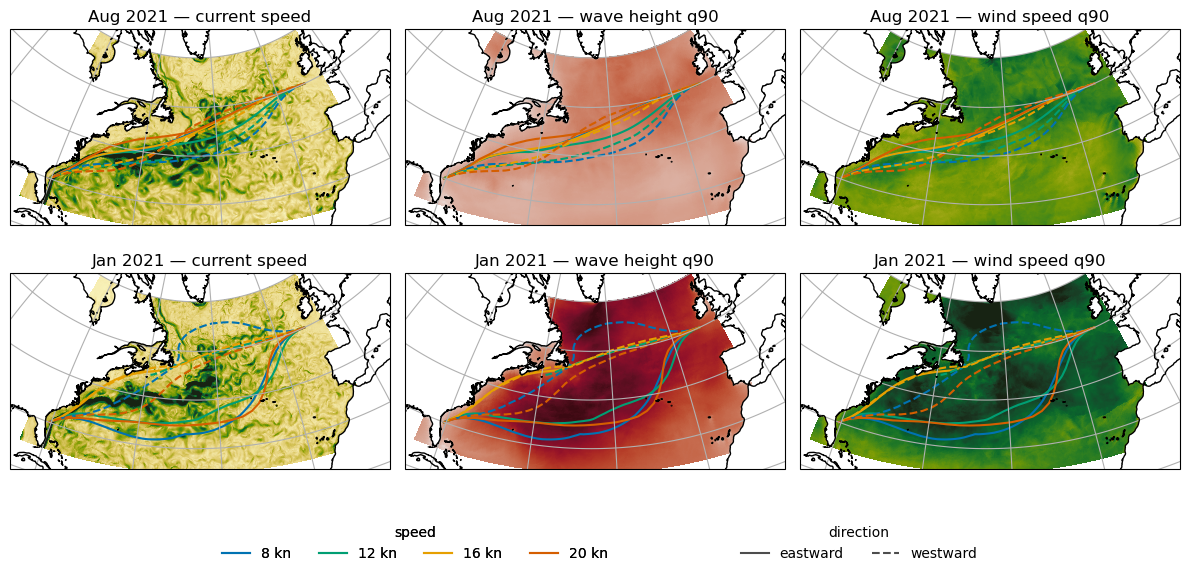

In [6]:
from matplotlib.lines import Line2D

proj = cartopy.crs.Stereographic(
    central_latitude=LAT_CENT, central_longitude=LON_CENT
)
transform = cartopy.crs.PlateCarree()

MONTHS = [
    {"month": 8, "label": "Aug 2021"},
    {"month": 1, "label": "Jan 2021"},
]

# Line styles per (direction, speed), derived from CASES so a 5th speed
# propagates. Encoding: colour = speed (SPEED_COLORS), linestyle = direction
# (DIRECTION_LINESTYLES: forward/eastward solid, backward/westward dashed).
ROUTE_STYLES = []
_seen = set()
for case in CASES:
    key = (case["direction"], case["speed"])
    if key in _seen:
        continue
    _seen.add(key)
    short = "E" if case["direction"] == "eastward" else "W"
    ROUTE_STYLES.append(
        {
            "direction": case["direction"],
            "speed": case["speed"],
            "color": SPEED_COLORS[case["speed"]],
            "ls": DIRECTION_LINESTYLES[case["journey"]],
            "label": f"{short} {case['speed']}kn",
        }
    )

COL_LABELS = ["current speed", "wave height q90", "wind speed q90"]

fig, axes = plt.subplots(
    len(MONTHS), 3,
    subplot_kw={"projection": proj},
    figsize=(3 * 4, len(MONTHS) * 3),
    sharex=True,
    sharey=True,
)

for i, minfo in enumerate(MONTHS):
    month_idx = minfo["month"] - 1

    # Current speed
    monthly_current_speed.isel(time=month_idx).plot(
        vmin=0, vmax=current_vmax, extend="max",
        cmap=cmocean.cm.speed, ax=axes[i, 0],
        transform=transform, rasterized=True, add_colorbar=False,
    )

    # Wave height q90
    monthly_wave_height.isel(time=month_idx).plot(
        vmin=0, vmax=wave_vmax, extend="max",
        cmap=cmocean.cm.amp, ax=axes[i, 1],
        transform=transform, rasterized=True, add_colorbar=False,
    )

    # Wind speed q90
    monthly_wind_speed.isel(time=month_idx).plot(
        vmin=0, vmax=wind_vmax, extend="max",
        cmap=cmocean.cm.speed, ax=axes[i, 2],
        transform=transform, rasterized=True, add_colorbar=False,
    )

    for j, col_label in enumerate(COL_LABELS):
        axes[i, j].set_title(f"{minfo['label']} — {col_label}")

    # Overlay all 8 routes (4 speeds x 2 directions) for this month
    for rs in ROUTE_STYLES:
        month_short = minfo["label"].split()[0]
        key = f"{month_short} {rs['label']}"
        route = best_routes[key]
        for j in range(3):
            axes[i, j].plot(
                route["lons"], route["lats"],
                transform=transform,
                color=rs["color"], linestyle=rs["ls"],
                linewidth=1.5,
            )

    # Map features
    for j in range(3):
        axes[i, j].add_feature(cartopy.feature.LAND, facecolor="white", zorder=2)
        axes[i, j].coastlines(zorder=3)
        axes[i, j].gridlines(draw_labels=False)
        axes[i, j].set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX])

# Legend: a speed colour key + a direction linestyle key (two separate keys so
# both encodings stay readable).
speed_handles = [
    Line2D([0], [0], color=SPEED_COLORS[s], lw=1.5, label=f"{s} kn")
    for s in sorted({c["speed"] for c in CASES})
]
dir_handles = [
    Line2D([0], [0], color="0.3", lw=1.5,
           linestyle=DIRECTION_LINESTYLES["Atlantic_forward"], label="eastward"),
    Line2D([0], [0], color="0.3", lw=1.5,
           linestyle=DIRECTION_LINESTYLES["Atlantic_backward"], label="westward"),
]
leg_speed = fig.legend(
    handles=speed_handles, loc="lower center", bbox_to_anchor=(0.35, 0.0),
    ncol=len(speed_handles), frameon=False, title="speed",
)
fig.add_artist(leg_speed)
fig.legend(
    handles=dir_handles, loc="lower center", bbox_to_anchor=(0.72, 0.0),
    ncol=len(dir_handles), frameon=False, title="direction",
)

fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.savefig(f"{FIG_DIR}/030_test_case_overview.png", dpi=150)
fig.savefig(f"{FIG_DIR}/030_test_case_overview.pdf", dpi=150)
plt.show()